In [4]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.bin_1d import Tile2Symb1dBin

from tests.experimental.grayscale.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 14
MAX_WIDTH = 80
MAX_HEIGHT = 24
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]


def make_converter(params: Params):
    return Tile2Symb1dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.0279 | Max: 0.0519 | Mean: 0.0444 | Std: 0.0086
Min: 0.0921 | Max: 0.1241 | Mean: 0.1096 | Std: 0.0140
Min: 0.0905 | Max: 0.1393 | Mean: 0.1162 | Std: 0.0188
Min: 0.1027 | Max: 0.1390 | Mean: 0.1203 | Std: 0.0128
Min: 0.0868 | Max: 0.1201 | Mean: 0.1042 | Std: 0.0126
Min: 0.1013 | Max: 0.1338 | Mean: 0.1215 | Std: 0.0128
Min: 0.0993 | Max: 0.1410 | Mean: 0.1200 | Std: 0.0138
Min: 0.0978 | Max: 0.1303 | Mean: 0.1172 | Std: 0.0111
Min: 0.1020 | Max: 0.1390 | Mean: 0.1228 | Std: 0.0146


C:\Users\wojte\AppData\Local\Temp\ipykernel_24660\4009546293.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


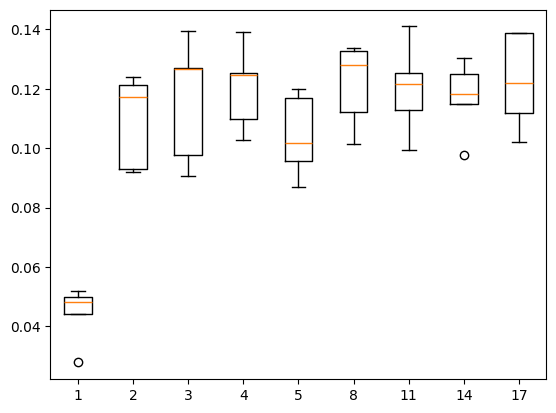

In [2]:
# bins

params_space = [
    bins for bins in range(1, 5, 1)
]
params_space += [
    bins for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.0741 | Max: 0.1014 | Mean: 0.0853 | Std: 0.0113
Min: 0.0911 | Max: 0.1215 | Mean: 0.1108 | Std: 0.0115
Min: 0.1070 | Max: 0.1529 | Mean: 0.1342 | Std: 0.0167
Min: 0.1249 | Max: 0.1701 | Mean: 0.1528 | Std: 0.0165
Min: 0.1337 | Max: 0.1863 | Mean: 0.1684 | Std: 0.0195


C:\Users\wojte\AppData\Local\Temp\ipykernel_24660\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


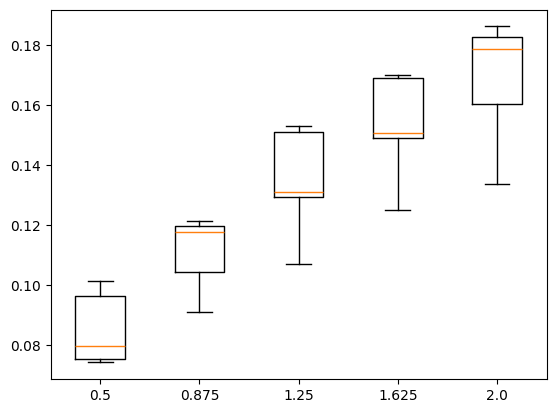

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [7]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2Symb1dBin(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    win_width = math.ceil(img.size[0] / MAX_WIDTH)
    win_height = math.ceil(img.size[1] / MAX_HEIGHT)
    results.append(converter.process_image(img, (win_width, win_height)))

print_gallery(results, 1)

---------------------------------------------------------------------------
 | ^^;:;";;^_,'~_',-~:_,_^"=!^;^^";";^;^;;^;;"^^^^^^:----;"^:'~,__--. -` | 
 | :;;=|\\>1<1<r+7({l{{?)t+r<vIcti**=;;/!1>(JivcL<>++rrr*</|\/|""|^:---  | 
 | .`   `.`--`-`-----_^^<>1+>*]r<>|;~--.- ---";";\+>|=;^'_-----:^~;,-. . | 
 | `..``.```.``....`.,";':,--.````.`` ``` ` `_:- ` ````.    ```.. . . .  | 
 | 7JI)vvr*1>/=\\\\!!<1|1rr!"^_~_~::~-------~,~,--   ```. `.``.``...```  | 
 | Foe2oU5O%qXDHmmdHDbpHHWDDm8WmmDHbdHDdHdHHddU6qXOwU#k9GeASASzyVl[]?l[; | 
 | eAoow9OKOE8WddbbbDp8WWdD888DmddDWHWWHWWd8ppWHbD8mmmpHm4hOk4h94AAASe2| | 
 | oSA6699EPmpHWDmbmdWmDbdd8Ddmmpdbm8mHbDWmb8HDdmHdWW8dddUUU9qXXkSAoo2o= | 
 | 2AZo%qXUKGpbH8m8p8WHd88WdHbHH8WpbdWbpppHHpHHmHdDbDpbKdp9Ow##w9eaa22o\ | 
 | oSAXqXO46WdDDmHbmb8DHDhpHpbdHHDbbdbm8bHWWm8HbmH8bpbdd88m64wG94qhZA2o/ | 
 | AAAK6q#WHDpHWdbWWm{=",'_'^^"^(aPH88pmHDdpmH8bdHpm8Ddmpddb#q6X%%G2oZa! | 
 | Ak#E65bdDpWWdD@$RJ,--_-:~~,,--,~;fHbddmpdWDbWpmmpppmDbHWDp%hXk%9EAaA\ | 
 | aA966wWmH